# Praktikum Kecerdasan Artifisial Lanjutan


---
## Bab 9. Clustering K-Means dan DBSCAN


### 1) Import Data

Praktikum kali ini menggunakan dataset bunga Iris dari UCI Machine Learning Repository. Unduh dataset yang akan digunakan pada praktikum kali ini. Anda dapat menggunakan aplikasi wget untuk mengunduh dataset dan menyimpannya dalam Google Colab. Jalankan cell di bawah ini untuk mengunduh dataset.

In [1]:
! wget https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data

--2026-05-06 16:06:17--  https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘iris.data.4’

iris.data.4             [ <=>                ]   4.44K  --.-KB/s    in 0s      

2026-05-06 16:06:17 (87.0 MB/s) - ‘iris.data.4’ saved [4551]



Setelah dataset berhasil diunduh, langkah berikutnya adalah membaca dataset dengan memanfaatkan fungsi **readcsv** dari library pandas. Lakukan pembacaan berkas csv ke dalam dataframe dengan nama **data** menggunakan fungsi **readcsv**. Jangan lupa untuk melakukan import library pandas terlebih dahulu


In [2]:
import pandas as pd
data = pd.read_csv('iris.data', header=None, names=['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species'])



Cek isi dataset Anda dengan menggunakan perintah **head()**

In [3]:
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## 2) Preprocessing

Sebelum dilakukan proses clustering, perlu dilakukan beberapa tahapan pemrosesan awal data. Tahapan pertama adalah memisahkan kelas data dari dataframe, karena algoritma K-Means tidak memerlukan informasi kelas. Pisahkan kelas data ke dalam sebuah variabel bernama kelas.


In [4]:
kelas = data.pop('species')

Pada praktikum kali ini, kita akan memvisualisasikan data hasil clustering menggunakan scatter plot. Scatter plot hanya dapat digambarkan dalam bentuk 2 dimensi, dengan demikian data yang digunakan juga hanya terdiri dari 2 fitur. Hapus fitur petal_length dan petal_width pada data, sehingga fitur yang digunakan adalah sepal_length dan sepal_width

In [5]:
if 'petal_length' in data.columns:
    del data['petal_length']
if 'petal_width' in data.columns:
    del data['petal_width']

Tampilkan data setelah penghapusan fitur petal_length dan petal_width

In [6]:
data

,sepal_length,sepal_width
0,5.1,3.5
1,4.9,3.0
2,4.7,3.2
3,4.6,3.1
4,5.0,3.6
...,...,...
145,6.7,3.0
146,6.3,2.5
147,6.5,3.0
148,6.2,3.4


Salah satu tahap pada algoritma clustering adalah perhitungan jarang Euclidean. Agar tidak ada fitur yang mendominasi pada perhitungan jarak, maka perlu dilakukan normalisasi terlebih dahulu agar rentang nilai setiap fitur sama. Implementasikan metode normalisasi min-max menggunakan fungsi bernama minmax pada cell di bawah ini.

In [7]:
def minmax(df_input):
    list_fitur = df_input.columns[:-1]
    for fitur in list_fitur:
        max = df_input[fitur].max()
        min = df_input[fitur].min()
        df_input[fitur] = (df_input[fitur] - min) / (max - min)
    return df_input

Lakukan normalisasi data dan simpan hasilnya pada variabel bernama data_normal

In [8]:
data_normal = minmax(data)

Tampilkan isi dataframe data_normal

In [9]:
data_normal

,sepal_length,sepal_width
0,0.222222,3.5
1,0.166667,3.0
2,0.111111,3.2
3,0.083333,3.1
4,0.194444,3.6
...,...,...
145,0.666667,3.0
146,0.555556,2.5
147,0.611111,3.0
148,0.527778,3.4


## 3) Visualisasi Data

Visualisasi data dilakukan untuk memahami struktur dari data. Informasi ini dapat digunakan untuk mengetahui cara pembentukan cluster yang baik. Visualisasikan data_normal menggunakan scatter plot. Gunakan library matplotlib.pyplot

[]

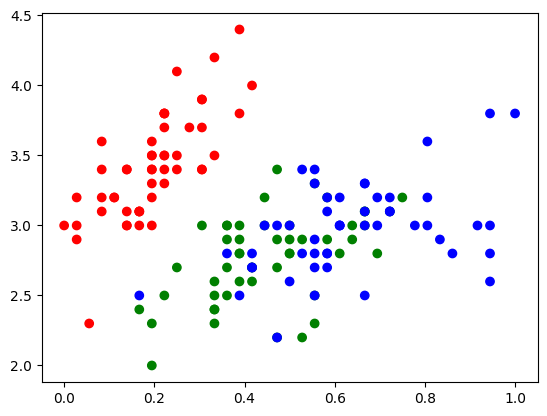

In [10]:
import matplotlib.pyplot as plt

warna = {'Iris-setosa': 'red', 'Iris-versicolor': 'green', 'Iris-virginica': 'blue'}
plt.scatter(data_normal['sepal_length'], data_normal['sepal_width'], c =kelas.map(warna))
plt.plot()

Fungsi scatter pada matplotlib menerima input berupa nilai variabel x, nilai variabel y, dan informasi kelas yang akan digunakan untuk membedakan warna elemen scatter plot.

## 4)  K-MEANS Clustering

Sebelum mengimplementasikan algoritma K-Means, perlu dilakukan implementasi perhitungan jarak. K-Means pada praktikum ini menggunakan perhitungan jarak Euclidean. Implementasikan perhitungan jarak Euclidean menggunakan fungsi bernama euclidean pada cell di bawah ini

In [11]:
import numpy as np

def euclidean(data1, data2):
    jarak = np.square(data1 - data2)
    jarak = np.sum(jarak)
    return np.sqrt(jarak)



Langkah selanjutnya adalah implementasi algoritma K-Means. Tahapan-tahapan dalam algoritma K-Means adalah:
1. Penentuan keanggotaan cluster secara acak
2. Hitung centroid berdasarkan data yang ada di masing-masing cluster
3. Alokasikan masing-masing data ke centroid terdekat
4. Kembali ke langkah 2 selama kondisi berhenti belum terpenuhi.
   *   Iterasi berhenti jika salah satu kondisi berikut terpenuhi
   *   Tidak ada perubahan keanggotaan cluster b. Iterasi melebihi parameter iter_max



Implementasikan algoritma K-Means menggunakan fungsi bernama kmeans pada cell di bawah ini. Fungsi kmeans memiliki 3 parameter input, yaitu data, K, dan iter_max

In [12]:
from random import randint
import copy

def kmeans(data_input, k, iter_max=200):
    n_data = data_input.shape[0]
    n_fitur = data_input.shape[1]
    iter = 1
    cluster = np.array([randint(0, k-1) for i in range(n_data)])
    centroid = np.zeros((k, n_fitur))
    cluster_tidak_berubah = False
    while not cluster_tidak_berubah and iter < iter_max:
        jarak = np.zeros((n_data, k))
        for i in range(k):
            centroid[i,:] = data_input.iloc[np.where(cluster == i)[0]].mean().tolist()
        for i in range(n_data):
            for j in range(k):
                jarak[i,j] = euclidean(data_input.iloc[i], centroid[j])
        cluster_baru = [np.argmin(jarak[i]) for i in range(n_data)]
        cluster_tidak_berubah = np.array_equal(cluster_baru, cluster)
        cluster = np.array(copy.deepcopy(cluster_baru))
        iter += 1
    return cluster, centroid, jarak

*   Pada fungsi tersebut, variabel cluster berisi keanggotan cluster dari masing-masing data. Variabel cluster awalnya bernilai acak dengan rentang 0 sampai dengan k-1. Variabel centroid merupakan centroid masing,masing cluster dengan struktur data berupa matriks berdimensi k x banyak fitur. Variabel cluster_tidak_berubah merupakan variabel Boolean yang menandakan apakah keanggotaan cluster yang terbentuk pada iterasi sekarang sama dengan keanggotaan cluster yang terbentuk pada iterasi sebelumnya.
*   Proses clustering terjadi di dalam looping while. Looping akan terus dilakukan selama masih terjadi perubahan keanggotaan cluster (cluster_tidak_berubah = False) dan iterasi kurang dari iterasi maksimum (iter<iter_max).
*   Tahapan pertama dalam looping adalah menghitung centroid, yang merupakan rata-rata data pada masing-masing cluster. Selanjutnya, jarak setiap data dengan setiap centroid dihitung dan disimpan pada variabel jarak. Keanggotaan cluster yang baru diperoleh dari indeks jarak dengan nilai minimum dari masing-masing data ke centroid dan disimpan pada variabel cluster_baru. Setelah itu, dilakukan perbandingan dengan variabel cluster, untuk mengecek apakah ada perubahan keanggotaan cluster pada interasi sebelumnya. Jika ada perubahan, variabel cluster_tidak_berubah berisi nilai False, sedangkan jika tidak ada perubahan maka variabel cluster_tidak_berubah berisi nilai True.





Lakukan proses clustering dengan memanggil fungsi kmeans dengan parameter input berupa data_normal dan k=3.

In [13]:
cluster = kmeans(data_normal, 3)

Tampilkan keanggotaan cluster pada masing-masing data

In [14]:
print(cluster)

(array([1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 1,
       1, 2, 1, 1, 1, 1, 0, 0, 0, 2, 2, 2, 0, 2, 0, 2, 2, 0, 2, 0, 2, 0,
       0, 2, 2, 2, 0, 2, 2, 2, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 0, 1, 0, 2,
       0, 2, 2, 0, 2, 2, 2, 0, 2, 0, 2, 2, 0, 2, 0, 0, 0, 0, 2, 0, 2, 0,
       0, 2, 0, 2, 2, 0, 0, 0, 2, 2, 0, 2, 0, 2, 0, 0, 2, 0, 2, 0, 0, 0,
       2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 0]), array([[0.6399177 , 3.0962963 ],
       [0.22157623, 3.51395349],
       [0.38155136, 2.63773585]]), array([[0.58090119, 0.01396843, 0.87686102],
       [0.48294877, 0.51687837, 0.42120155],
       [0.53887926, 0.33282027, 0.62392219],
       [0.55659668, 0.43642707, 0.55011102],
       [0.67243129, 0.0902227 , 0.98028633],
       [0.87048129, 0.39507523, 1.26454978],
       [0.63405212, 0.17915495, 0.81852344],
       [0.53914966, 0.11713894, 0.78489212],
       [0.6428433 , 0.6438142 , 0.440

Tampilkan hasil clustering menggunakan scatter plot

[]

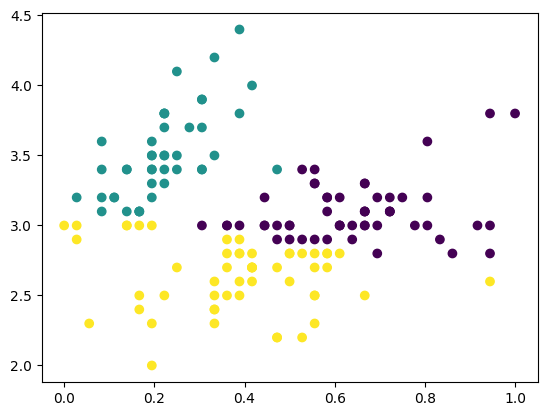

In [15]:
plt.scatter(data_normal['sepal_length'], data_normal['sepal_width'], c = cluster[0])
plt.plot()

## 5) DBSCAN Clustering

Pada praktikum ini, implementasikan algoritma DBSCAN menggunakan pustaka sklearn. Terdapat dua parameter penting yang di diatur pada program yaitu eps dan min_sample. Eps adalah jarak maksimum antara dua sampel agar satu sampel dianggap berada di sekitar sampel lainnya. Parameter ini harus dipilih dengan tepat untuk set data dan fungsi jarak. Nilai default dari parameter eps adalah 0.5. Min_sample adalah jumlah sampel (atau bobot total) di lingkungan sekitar agar suatu titik dianggap sebagai titik inti (termasuk titik itu sendiri). Jika min_samples ditetapkan tinggi, maka DBSCAN akan membentuk klaster yang lebih padat, sedangkan jika ditetapkan rendah, maka klaster yang terbentuk akan lebih jarang. Nilai default dari parameter min_sample adalah 5.

In [16]:
from sklearn.cluster import DBSCAN

epsilon = 0.11
min_samples = 5
dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)
cluster = dbscan.fit_predict(data_normal)

Tampilkan keanggotaan cluster pada masing-masing data

In [17]:
print(cluster)

[ 0  0  0  0  0 -1  0  0 -1  0  0  0  0 -1 -1 -1 -1  0 -1  0  0  0 -1  0
  0  0  0  0  0  0  0  0 -1 -1  0  0  0  0 -1  0  0 -1  0  0  0  0  0  0
  0  0  1  1  1  1  1  1  1 -1  1 -1 -1  1 -1  1  1  1  1  1 -1  1 -1  1
 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1 -1  1  1
  1  1 -1  1  1  1  1  1  1 -1 -1 -1 -1 -1  1  1  1  1  1  1  1 -1 -1 -1
  1  1 -1  1  1  1  1  1  1 -1 -1 -1  1  1  1 -1  1  1  1  1  1  1  1  1
  1  1 -1  1  1  1]


Tampilkan hasil clustering menggunakan scatter plot

[]

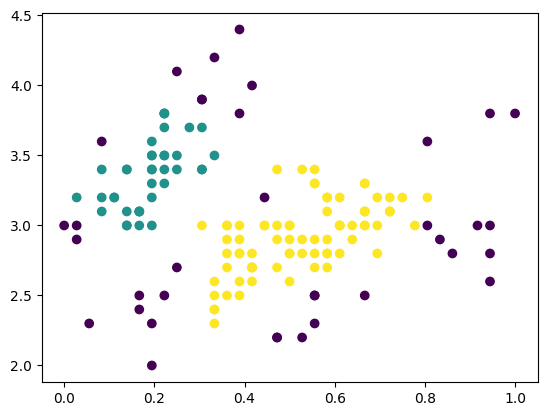

In [18]:
plt.scatter(data_normal['sepal_length'], data_normal['sepal_width'], c = cluster)
plt.plot()

## TUGAS
Pada tugas kali ini anda diminta mengidentifikasikan pasangan fitur apa yang menghasilkan cluster yang ideal pada K-Means dan DBSCAN menggunakan data Iris. Langkah yang harus dilakukan adalah:

1.	Buatlah plot untuk setiap pasangan fitur yang mungkin.

2.	Lihatlah plot yang terbentuk. Identifikasikan pasangan fitur apa yang dapat membedakan cluster dengan baik. Hal ini ditandai dengan plot yang memiliki warna-warna yang saling berpisah atau tidak bercampur.

3.	Lakukan clustering menggunakan K-Means dengan k=3 dan DBSCAN. Lalu amati apakah cluster yang dihasilkan dapat terpisah dengan baik.

### Nomor 1

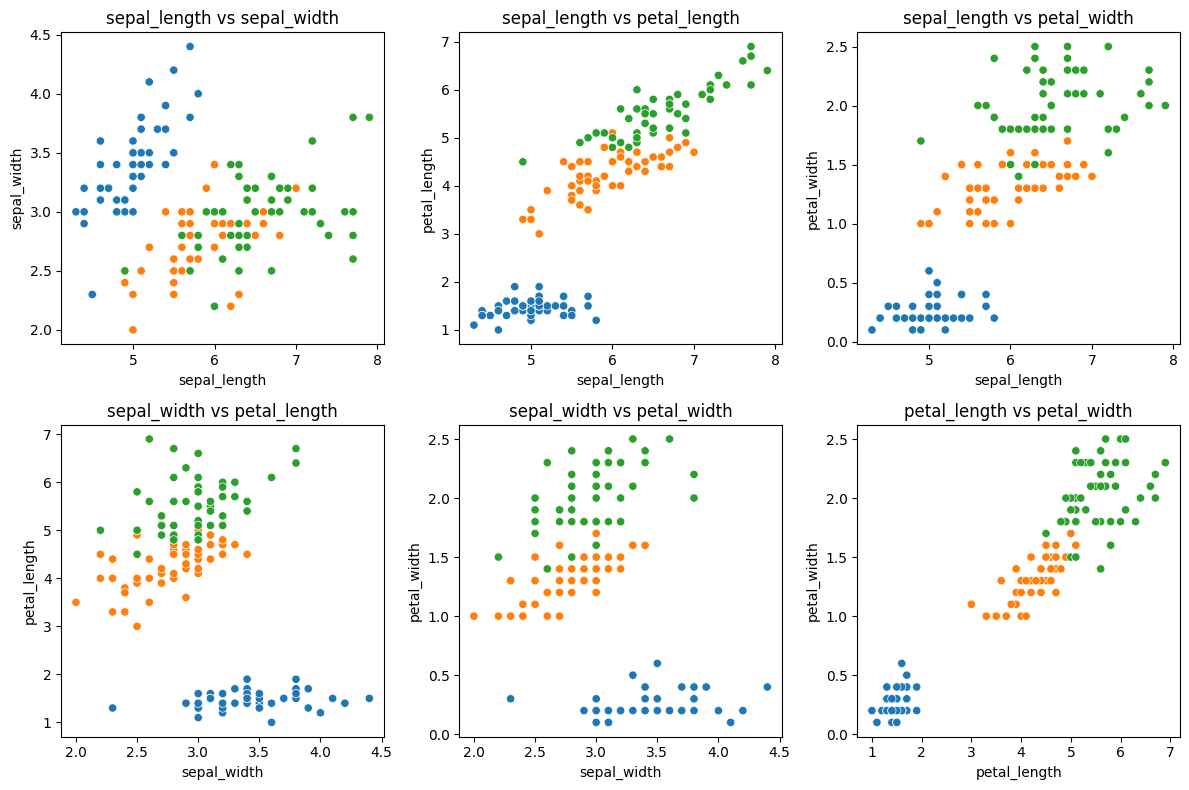

In [ ]:
from itertools import combinations
import seaborn as sns

data_tugas = pd.read_csv('iris.data', header=None, names=['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species'])

fitur = data_tugas.columns[:-1] 
pasangan = list(combinations(fitur, 2))

plt.figure(figsize=(12, 8))

for i, (f1, f2) in enumerate(pasangan):
    plt.subplot(2, 3, i+1)
    sns.scatterplot(x=data_tugas[f1], y=data_tugas[f2], hue=data_tugas['species'])
    plt.title(f"{f1} vs {f2}")
    plt.legend().remove()

plt.tight_layout()
plt.show()

### Nomor 2
Jika dilihat dari plot yang terbentuk, pasangan fitur yang dapat membedakan cluster dengan baik adalah petal length dengan petal width, sepal length dengan petal width, dan sepal width dengan petal width. Plot pasangan petal length dengan petal width menunjukkan pemisahan warna plot yang paling jelas. Sementara itu, plot pasangan sepal length dengan petal width serta pasangan sepal width dengan petal width juga menunjukkan pemisahan yang cukup baik, meskipun masih terdapat sedikit tumpang tindih antar cluster. 

### Nomor 3

In [ ]:
kelas_tugas = data_tugas.pop('species')
if 'sepal_length' in data_tugas.columns:
    del data_tugas['sepal_length']
if 'sepal_width' in data_tugas.columns:
    del data_tugas['sepal_width']
data_normal_tugas = minmax(data_tugas) 

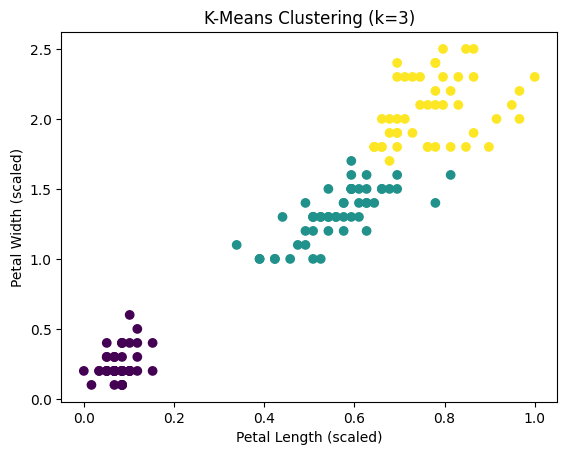

In [22]:
# KMeans
cluster = kmeans(data_normal_tugas, 3)
plt.scatter(data_normal_tugas['petal_length'], data_normal_tugas['petal_width'], c = cluster[0])
plt.title("K-Means Clustering (k=3)")
plt.xlabel("Petal Length (scaled)")
plt.ylabel("Petal Width (scaled)")
plt.show()

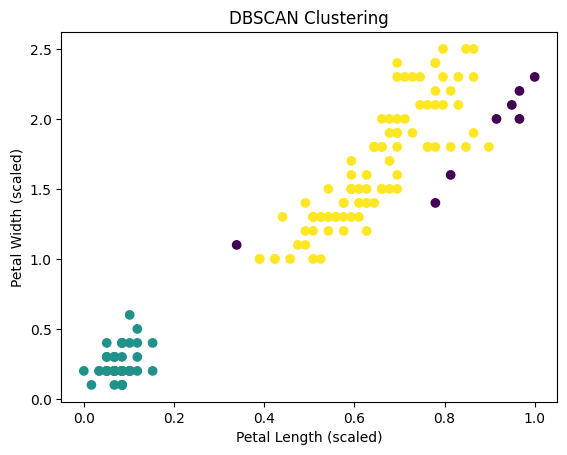

In [23]:
# DBSCAN
epsilon = 0.11
min_samples = 5
dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)
cluster = dbscan.fit_predict(data_normal_tugas)
plt.scatter(data_normal_tugas['petal_length'], data_normal_tugas['petal_width'], c = cluster)
plt.title("DBSCAN Clustering")
plt.xlabel("Petal Length (scaled)")
plt.ylabel("Petal Width (scaled)")
plt.show()

Pada tahap ini, dilakukan proses clustering menggunakan algoritma K-Means (k=3) dan DBSCAN dengan memanfaatkan pasangan fitur terbaik, yaitu petal length dan petal width. Hasil clustering dengan K-Means menunjukkan bahwa data berhasil dikelompokkan menjadi tiga cluster dengan sangat baik. Setiap cluster tampak terpisah secara jelas tanpa banyak tumpang tindih. Hal ini menunjukkan bahwa K-Means mampu menangkap struktur alami data dengan optimal.

Sedangkan pada algoritma DBSCAN, hasil clustering menunjukkan bahwa cluster utama masih dapat teridentifikasi, terutama untuk kelompok yang memiliki jarak yang jelas dari kelompok lain. Namun, terdapat beberapa titik data yang tidak terkelompok dengan baik atau dianggap sebagai noise. Selain itu, DBSCAN cenderung kesulitan dalam memisahkan dua cluster yang memiliki jarak yang berdekatan, sehingga hasilnya tidak seoptimal K-Means dalam kasus ini.

Dengan demikian, K-Means menunjukkan performa yang lebih baik dibandingkan DBSCAN pada dataset Iris. K-Means mampu menghasilkan jumlah cluster yang sesuai dan pemisahan yang lebih jelas, sedangkan DBSCAN cenderung menghasilkan cluster yang kurang optimal dan sensitif terhadap parameter.